# Machine Learning — Notebook 09
## Support Vector Machines: margen, kernels y tuning

### Objetivos
- Entender SVM como un **clasificador de margen máximo**.
- Ver cómo `C` controla el trade-off entre margen grande y errores de clasificación.
- Introducir el **truco del kernel**: mapear a dimensión superior sin calcular las coordenadas.
- Visualizar fronteras de decisión con kernel **lineal** y **RBF**.
- Entender el efecto de `gamma` en el kernel RBF.
- Hacer tuning mínimo de `C` y `gamma` con validación cruzada.
- Comparar SVM vs los modelos anteriores mediante curvas **ROC** y **PR**.

### Ideas clave
- SVM busca el hiperplano que **maximiza el margen** entre las clases.
- `C` pequeño → margen grande, más errores tolerados (más sesgo, menos varianza).
- `C` grande → margen pequeño, pocos errores en train (menos sesgo, más varianza).
- El kernel RBF mide similitud como $k(x, x') = \exp(-\gamma \|x - x'\|^2)$.
- `gamma` pequeño → influencia larga (frontera suave). `gamma` grande → influencia local (frontera rugosa).
- SVM **requiere escalado** (distancias son sensibles a escala).

> Trabajaremos primero en 2D para ver las fronteras, y luego con el dataset tabular para el tuning y comparación.

---
## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification, make_circles, make_moons

RANDOM_STATE = 7
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 200)

---
## 1) SVM Lineal: margen máximo

SVM lineal busca el hiperplano $\mathbf{w}^\top \mathbf{x} + b = 0$ que maximiza el **margen**:

$$
\text{margen} = \frac{2}{\|\mathbf{w}\|}
$$

Con penalización por errores (soft-margin, parámetro `C`):

$$
\min_{\mathbf{w},b,\xi}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i
\quad \text{s.t.}\; y_i(\mathbf{w}^\top \mathbf{x}_i + b) \ge 1 - \xi_i,\; \xi_i \ge 0
$$

Los **vectores de soporte** son los puntos que están justo en el margen o dentro de él.

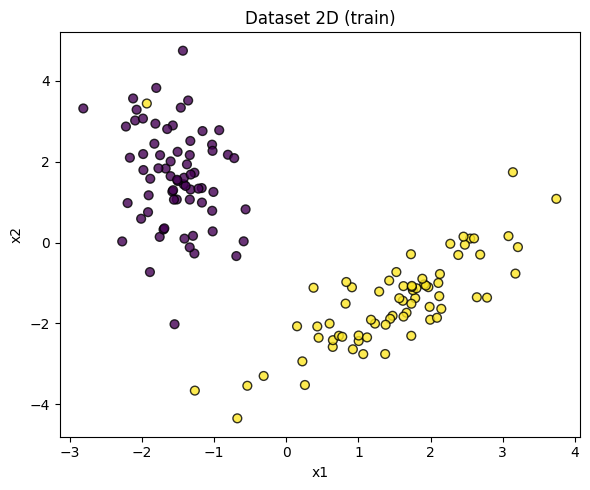

In [2]:
# 1.1 Dataset 2D linealmente separable (casi)
X2, y2 = make_classification(
    n_samples=200, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    class_sep=1.5, flip_y=0.02, random_state=RANDOM_STATE
)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=RANDOM_STATE, stratify=y2
)

plt.figure(figsize=(6, 5))
plt.scatter(X2_train[:, 0], X2_train[:, 1], c=y2_train,
            edgecolor="k", alpha=0.8, s=40)
plt.title("Dataset 2D (train)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

In [3]:
def plot_svm_boundary(model, X, y, title="SVM boundary", steps=300):
    """Visualiza la frontera de un clasificador 2D con zona de margen (si es SVM lineal)."""
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, steps),
        np.linspace(x2_min, x2_max, steps)
    )
    grid = np.c_[xx1.ravel(), xx2.ravel()]

    # Usar decision_function si está disponible (SVC), si no predict_proba
    try:
        Z = model.decision_function(grid).reshape(xx1.shape)
        plt.figure(figsize=(6, 5))
        plt.contourf(xx1, xx2, Z, levels=20, alpha=0.7)
        plt.contour(xx1, xx2, Z, levels=[-1, 0, 1],
                    linestyles=["--", "-", "--"], colors="k", linewidths=[1, 2, 1])
    except Exception:
        Z = model.predict_proba(grid)[:, 1].reshape(xx1.shape)
        plt.figure(figsize=(6, 5))
        plt.contourf(xx1, xx2, Z, levels=20, alpha=0.7)

    plt.colorbar()
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", alpha=0.8, s=35)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()

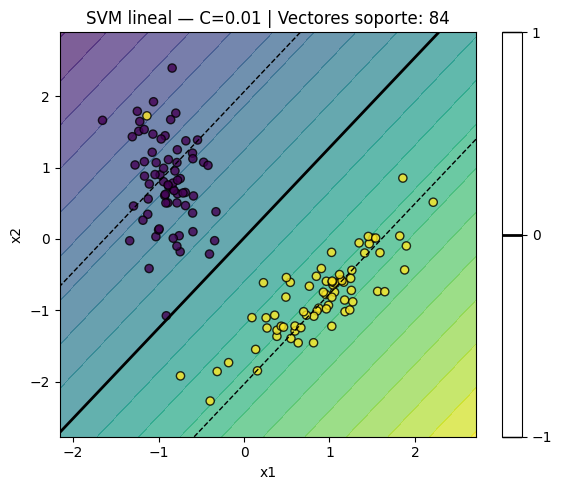

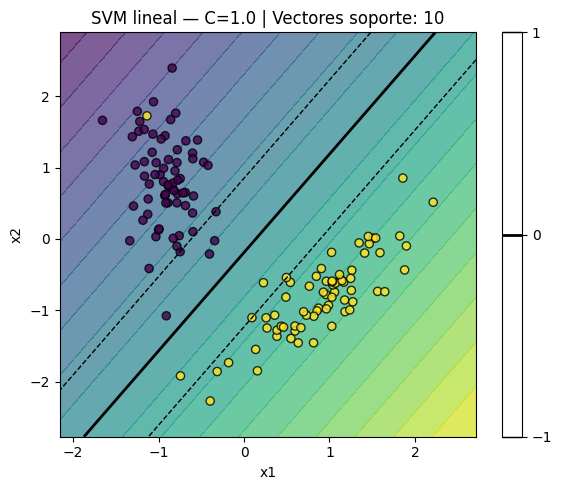

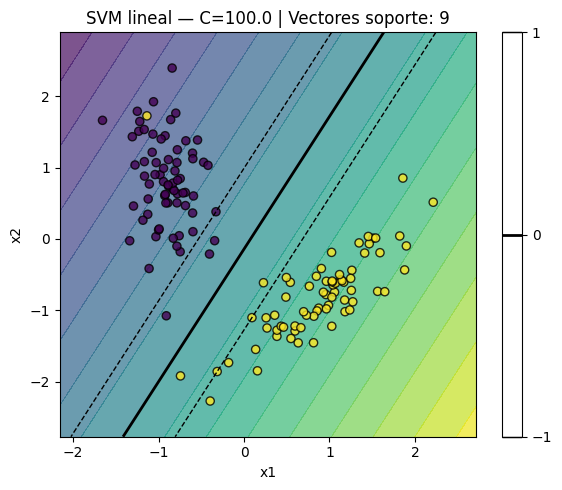

In [4]:
# 1.2 SVM lineal: efecto de C
scaler = StandardScaler()
X2_train_sc = scaler.fit_transform(X2_train)

for C_val in [0.01, 1.0, 100.0]:
    svm_lin = SVC(kernel="linear", C=C_val)
    svm_lin.fit(X2_train_sc, y2_train)
    n_sv = svm_lin.n_support_.sum()
    plot_svm_boundary(
        svm_lin, X2_train_sc, y2_train,
        title=f"SVM lineal — C={C_val} | Vectores soporte: {n_sv}"
    )

---
## 2) El truco del kernel: datos no linealmente separables

Cuando los datos **no son linealmente separables**, mapeamos a un espacio de mayor dimensión:

$$
\phi: \mathbb{R}^p \to \mathbb{R}^m, \quad m \gg p
$$

La clave es que no necesitamos calcular $\phi(x)$ explícitamente: solo necesitamos el **kernel**:

$$
k(x, x') = \langle \phi(x), \phi(x') \rangle
$$

**Kernel RBF (Gaussiano):**
$$
k(x, x') = \exp\!\left(-\gamma \|x - x'\|^2\right)
$$

- $\gamma$ pequeño → función de base amplia → frontera suave.
- $\gamma$ grande → función de base estrecha → frontera compleja (riesgo de sobreajuste).

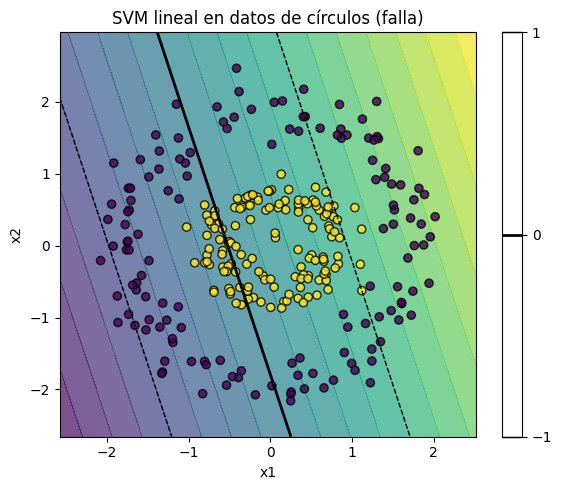

SVM lineal — Test accuracy: 0.558


In [5]:
# 2.1 Dataset no lineal: círculos concéntricos
X_circ, y_circ = make_circles(
    n_samples=400, factor=0.4, noise=0.12, random_state=RANDOM_STATE
)
X_circ_tr, X_circ_te, y_circ_tr, y_circ_te = train_test_split(
    X_circ, y_circ, test_size=0.30, random_state=RANDOM_STATE, stratify=y_circ
)

scaler_circ = StandardScaler()
X_circ_tr_sc = scaler_circ.fit_transform(X_circ_tr)
X_circ_te_sc = scaler_circ.transform(X_circ_te)

# SVM lineal falla
svm_lin_circ = SVC(kernel="linear", C=1.0)
svm_lin_circ.fit(X_circ_tr_sc, y_circ_tr)
plot_svm_boundary(svm_lin_circ, X_circ_tr_sc, y_circ_tr,
                  title="SVM lineal en datos de círculos (falla)")
print(f"SVM lineal — Test accuracy: {accuracy_score(y_circ_te, svm_lin_circ.predict(X_circ_te_sc)):.3f}")

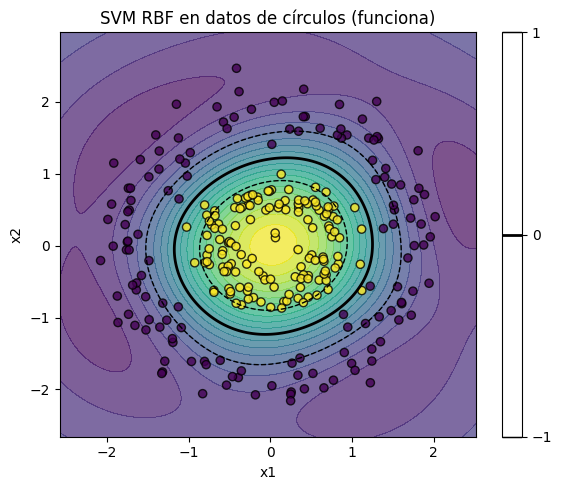

SVM RBF — Test accuracy: 0.983


In [6]:
# 2.2 Kernel RBF en datos no lineales
svm_rbf_circ = SVC(kernel="rbf", C=1.0, gamma="scale")
svm_rbf_circ.fit(X_circ_tr_sc, y_circ_tr)
plot_svm_boundary(svm_rbf_circ, X_circ_tr_sc, y_circ_tr,
                  title="SVM RBF en datos de círculos (funciona)")
print(f"SVM RBF — Test accuracy: {accuracy_score(y_circ_te, svm_rbf_circ.predict(X_circ_te_sc)):.3f}")

---
## 3) Efecto de C y gamma en el kernel RBF

| Parámetro | Bajo | Alto |
|---|---|---|
| `C` | Margen grande, más errores tolerados (más sesgo) | Margen pequeño, menos errores (más varianza) |
| `gamma` | Influencia amplia, frontera suave | Influencia local, frontera irregular |

In [7]:
# 3.1 Dataset 2D con estructura no lineal (lunas)
X_moon, y_moon = make_moons(
    n_samples=500, noise=0.18, random_state=RANDOM_STATE
)
X_moon_tr, X_moon_te, y_moon_tr, y_moon_te = train_test_split(
    X_moon, y_moon, test_size=0.30, random_state=RANDOM_STATE, stratify=y_moon
)

scaler_moon = StandardScaler()
X_moon_tr_sc = scaler_moon.fit_transform(X_moon_tr)
X_moon_te_sc = scaler_moon.transform(X_moon_te)

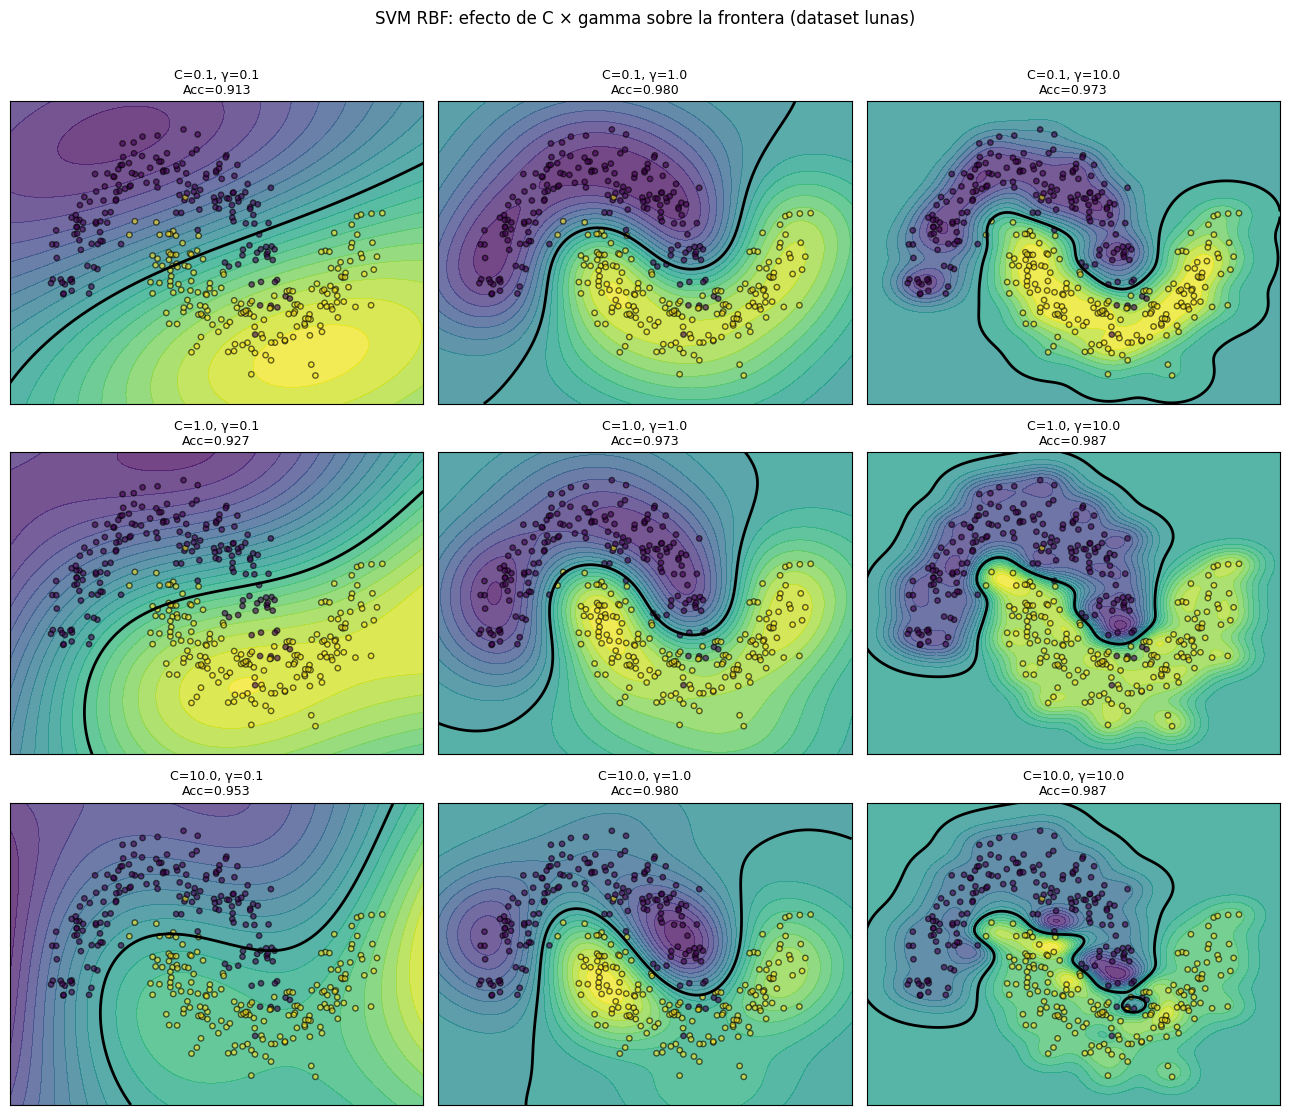

In [8]:
# 3.2 Mapa de fronteras para diferentes C y gamma
C_vals     = [0.1, 1.0, 10.0]
gamma_vals = [0.1, 1.0, 10.0]

steps = 200
x1_min, x1_max = X_moon_tr_sc[:, 0].min()-0.5, X_moon_tr_sc[:, 0].max()+0.5
x2_min, x2_max = X_moon_tr_sc[:, 1].min()-0.5, X_moon_tr_sc[:, 1].max()+0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, steps),
                        np.linspace(x2_min, x2_max, steps))
grid = np.c_[xx1.ravel(), xx2.ravel()]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for i, C_val in enumerate(C_vals):
    for j, g_val in enumerate(gamma_vals):
        svm = SVC(kernel="rbf", C=C_val, gamma=g_val)
        svm.fit(X_moon_tr_sc, y_moon_tr)
        Z = svm.decision_function(grid).reshape(xx1.shape)
        acc = accuracy_score(y_moon_te, svm.predict(X_moon_te_sc))

        ax = axes[i][j]
        ax.contourf(xx1, xx2, Z, levels=20, alpha=0.75)
        ax.contour(xx1, xx2, Z, levels=[0], colors="k", linewidths=2)
        ax.scatter(X_moon_tr_sc[:, 0], X_moon_tr_sc[:, 1],
                   c=y_moon_tr, edgecolor="k", s=15, alpha=0.6)
        ax.set_title(f"C={C_val}, γ={g_val}\nAcc={acc:.3f}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("SVM RBF: efecto de C × gamma sobre la frontera (dataset lunas)", y=1.01)
plt.tight_layout()
plt.show()

---
## 4) Tuning de C y gamma con validación cruzada

Usamos el **dataset tabular** (más realista que 2D) y buscamos los mejores `C` y `gamma`  
con `GridSearchCV`. Importante: el escalado va **dentro** del pipeline para evitar data leakage.

In [9]:
# 4.1 Dataset tabular
from sklearn.datasets import make_classification

X_tab, y_tab = make_classification(
    n_samples=2500, n_features=12, n_informative=6,
    n_redundant=3, weights=[0.68, 0.32],
    class_sep=1.0, flip_y=0.04, random_state=RANDOM_STATE
)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_tab, y_tab, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tab
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Train:", X_tr.shape, "| Test:", X_te.shape)

Train: (1875, 12) | Test: (625, 12)


In [10]:
# 4.2 Tuning manual: grid de C × gamma (rápido y transparente)
C_grid     = [0.01, 0.1, 1.0, 10.0, 100.0]
gamma_grid = ["scale", 0.001, 0.01, 0.1, 1.0]

rows = []
for C_val in C_grid:
    for g_val in gamma_grid:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=C_val, gamma=g_val, probability=True))
        ])
        scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="roc_auc")
        rows.append({
            "C": C_val, "gamma": str(g_val),
            "roc_auc_mean": scores.mean(),
            "roc_auc_std":  scores.std()
        })

df_grid = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
print("Top 5 configuraciones:")
df_grid.head(5)

Top 5 configuraciones:


,C,gamma,roc_auc_mean,roc_auc_std
15,10.0,scale,0.926515,0.008847
22,100.0,0.01,0.924636,0.006169
18,10.0,0.1,0.922860,0.007843
13,1.0,0.1,0.919531,0.013415
10,1.0,scale,0.916321,0.012249


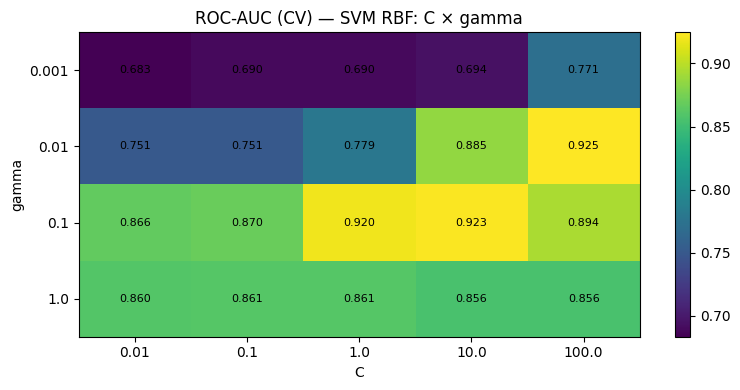

In [11]:
# 4.3 Heatmap de ROC-AUC para C × gamma
# Solo para gamma numérico (excluir "scale")
df_heat = df_grid[df_grid["gamma"] != "scale"].copy()
df_heat["gamma"] = df_heat["gamma"].astype(float)
pivot = df_heat.pivot(index="gamma", columns="C", values="roc_auc_mean")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title("ROC-AUC (CV) — SVM RBF: C × gamma")
plt.colorbar(im, ax=ax)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
# 4.4 Entrenar mejor config y evaluar en test
best_row = df_grid.iloc[0]
best_C   = best_row["C"]
best_g   = best_row["gamma"]

print(f"Mejor config: C={best_C}, gamma={best_g} — ROC-AUC CV: {best_row['roc_auc_mean']:.4f}")

svm_best = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=best_C,
                gamma=float(best_g) if best_g != "scale" else "scale",
                probability=True))
])
svm_best.fit(X_tr, y_tr)

pred_svm  = svm_best.predict(X_te)
proba_svm = svm_best.predict_proba(X_te)[:, 1]

print(f"Test Accuracy  : {accuracy_score(y_te, pred_svm):.4f}")
print(f"Test ROC-AUC   : {roc_auc_score(y_te, proba_svm):.4f}")
print(f"Test F1        : {f1_score(y_te, pred_svm):.4f}")

Mejor config: C=10.0, gamma=scale — ROC-AUC CV: 0.9265
Test Accuracy  : 0.8816
Test ROC-AUC   : 0.9369
Test F1        : 0.8186


---
## 5) SVM lineal vs RBF: ¿cuándo usar cada uno?

| Situación | Kernel recomendado |
|---|---|
| Alta dimensión ($p \gg n$), e.g. texto/NLP | Lineal |
| Dataset pequeño-mediano con no linealidad | RBF |
| Features heterogéneas con interacciones | RBF o polynomial |
| Se necesita interpretabilidad de coeficientes | Lineal |

In [13]:
# 5.1 Entrenar SVM lineal sobre el dataset tabular
svm_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0, probability=True))
])
svm_lin.fit(X_tr, y_tr)
pred_lin  = svm_lin.predict(X_te)
proba_lin = svm_lin.predict_proba(X_te)[:, 1]

print(f"SVM Lineal — Accuracy: {accuracy_score(y_te, pred_lin):.4f} | ROC-AUC: {roc_auc_score(y_te, proba_lin):.4f}")
print(f"SVM RBF   — Accuracy: {accuracy_score(y_te, pred_svm):.4f} | ROC-AUC: {roc_auc_score(y_te, proba_svm):.4f}")

SVM Lineal — Accuracy: 0.7504 | ROC-AUC: 0.6487
SVM RBF   — Accuracy: 0.8816 | ROC-AUC: 0.9369


---
## 6) Comparación ROC y PR: SVM vs modelos anteriores

Comparamos todos los modelos vistos hasta ahora en el mismo split train/test.  
- **ROC**: TPR vs FPR (útil para medir discriminación general).
- **PR**: Precisión vs Recall (más informativa cuando hay clases desbalanceadas).

In [14]:
# 6.1 Entrenar todos los modelos
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_tr, y_tr)

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=3000))
])
lr.fit(X_tr, y_tr)

rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_tr, y_tr)

all_models = {
    "Dummy": dummy,
    "LogReg": lr,
    "Random Forest": rf,
    "SVM Lineal": svm_lin,
    f"SVM RBF (C={best_C}, γ={best_g})": svm_best,
}

In [15]:
# 6.2 Tabla de métricas
metric_rows = []
for name, model in all_models.items():
    pred  = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    metric_rows.append({
        "Modelo": name,
        "Accuracy":    accuracy_score(y_te, pred),
        "BalancedAcc": balanced_accuracy_score(y_te, pred),
        "F1":          f1_score(y_te, pred, zero_division=0),
        "ROC_AUC":     roc_auc_score(y_te, proba),
        "PR_AUC":      average_precision_score(y_te, proba),
    })

pd.DataFrame(metric_rows).set_index("Modelo").round(4)

,Accuracy,BalancedAcc,F1,ROC_AUC,PR_AUC
Modelo,,,,,
Dummy,0.6720,0.5000,0.0000,0.5000,0.3280
LogReg,0.7184,0.6107,0.4094,0.6953,0.5858
Random Forest,0.8608,0.8253,0.7728,0.9245,0.8720
SVM Lineal,0.7504,0.6208,0.3906,0.6487,0.6343
"SVM RBF (C=10.0, γ=scale)",0.8816,0.8645,0.8186,0.9369,0.9083


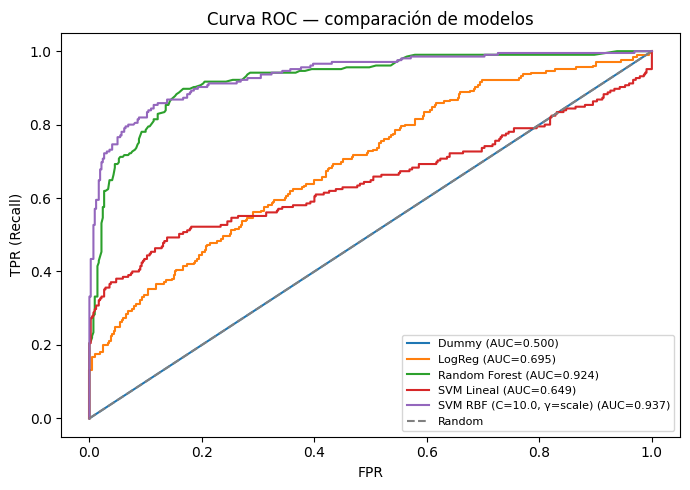

In [16]:
# 6.3 Curva ROC
plt.figure(figsize=(7, 5))
for name, model in all_models.items():
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc = roc_auc_score(y_te, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title("Curva ROC — comparación de modelos")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

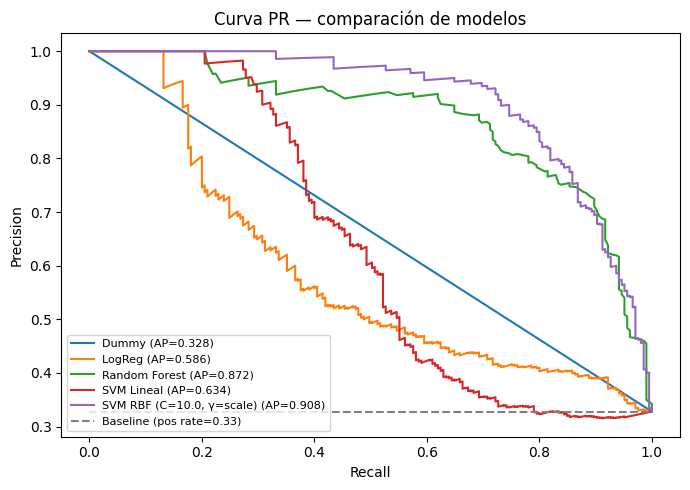

In [17]:
# 6.4 Curva PR
baseline_pos_rate = y_te.mean()

plt.figure(figsize=(7, 5))
for name, model in all_models.items():
    proba = model.predict_proba(X_te)[:, 1]
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
plt.hlines(baseline_pos_rate, 0, 1, linestyles="--",
           colors="gray", label=f"Baseline (pos rate={baseline_pos_rate:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva PR — comparación de modelos")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 7) Ejercicios (Semana 9)

### Ejercicio 1 — SVM lineal: efecto de C
1. En el dataset 2D de la sección 1, prueba `C = [0.001, 0.1, 1, 10, 1000]`.  
2. ¿Cómo cambia el número de vectores de soporte (`svm.n_support_.sum()`) con C?  
3. Explica la relación: *más vectores de soporte ↔ más margen ↔ más sesgo*.

### Ejercicio 2 — Kernel RBF: overfitting
1. En el dataset de lunas, entrena un SVM RBF con `C=1000` y `gamma=100`.  
2. Visualiza la frontera. ¿Qué ocurre? ¿Es lo que esperabas?  
3. Compara train accuracy vs test accuracy para detectar sobreajuste.

### Ejercicio 3 — Tuning mínimo
1. Repite el grid de la sección 4 pero usando **F1** como métrica en lugar de ROC-AUC.  
2. ¿Cambia la configuración óptima? ¿Cuándo usarías cada métrica para seleccionar el modelo?

### Ejercicio 4 — Curvas ROC y PR
1. ¿Cuál modelo tiene mejor ROC-AUC? ¿Y mejor PR-AUC?  
2. En un problema con clase positiva rara (5% positivos), ¿cuál de las dos curvas usarías y por qué?  
3. ¿SVM RBF mejora o empeora respecto a Random Forest en este dataset?

### Ejercicio 5 — Conceptual: SVM vs árboles vs logística
Completa la tabla comparativa con tus propias palabras:

| Modelo | Requiere escalado | Interpretable | Maneja no linealidad | Sensible a outliers |
|---|---|---|---|---|
| Logística | | | | |
| Árbol (un solo) | | | | |
| Random Forest | | | | |
| SVM lineal | | | | |
| SVM RBF | | | | |